# Togather — 2025 Demand Forecast & GMV Cascade

**Goal:** Forecast 2025 **demand (requests)** with Prophet, then cascade to **bookings** and **GMV**
(gross booking value) using 2024 segment conversion and ticket.

**Why forecast requests (not bookings/GMV directly):** requests are the densest, most stable series
(~150/day vs ~12 bookings/day). Bookings and GMV are sparse and noisy, so we forecast the reliable
top-of-funnel signal and derive the rest — see the cascade in Section 4 and the limitations in Section 5.

> **GMV vs revenue:** "GMV" is the booking value the customer pays the supplier. Togather's own revenue
> is a commission % of GMV (rate not in the data) — apply the take-rate to convert.

> **Note:** an earlier idea was to use `karpathy/autoresearch` for the forecast. That repo is **not** a
> forecasting tool — it is an autonomous LLM-training experiment. We use **Prophet** instead.

## 0. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
FIGURES = '../outputs/figures/'
RAW     = '../data/raw/'

def load_requests(path=RAW + 'food_requests.xlsx'):
    df = pd.read_excel(path, header=1)
    df.columns = ['event_request_id', 'created', 'region', 'priority_tag', 'request_budget']
    df['created'] = pd.to_datetime(df['created'], format='mixed')
    df['priority_tag'] = df['priority_tag'].str.strip()
    return df

def load_quotes(path=RAW + 'food_quotes.xlsx'):
    df = pd.read_excel(path)
    df.columns = ['quote_id', 'supplier_id', 'event_request_id', 'quote_created',
                  'booked', 'supplier_region', 'quote_price', 'supplier_primary_tag']
    df['quote_created'] = pd.to_datetime(df['quote_created'], format='mixed')
    df['booked'] = df['booked'].astype(int)
    df['supplier_primary_tag'] = df['supplier_primary_tag'].str.strip()
    return df

requests = load_requests()
quotes   = load_quotes()
print('Requests', requests.shape, '| Quotes', quotes.shape)
print('Date range:', requests['created'].min().date(), '->', requests['created'].max().date())

C:\Users\judme\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Requests (55104, 5) | Quotes (218351, 8)
Date range: 2024-01-01 -> 2024-12-31


## 1. Build the daily demand series (2024)

Daily granularity gives Prophet ~366 points so it can learn the strong **weekly** pattern (Mon high /
Sat low, seen in `02_analysis`) plus the **yearly** shape, with UK bank holidays as explicit effects.

Daily series: 2024-01-01 -> 2024-12-31 | days 366
Mean/day: 150.6 | min 0 | max 326


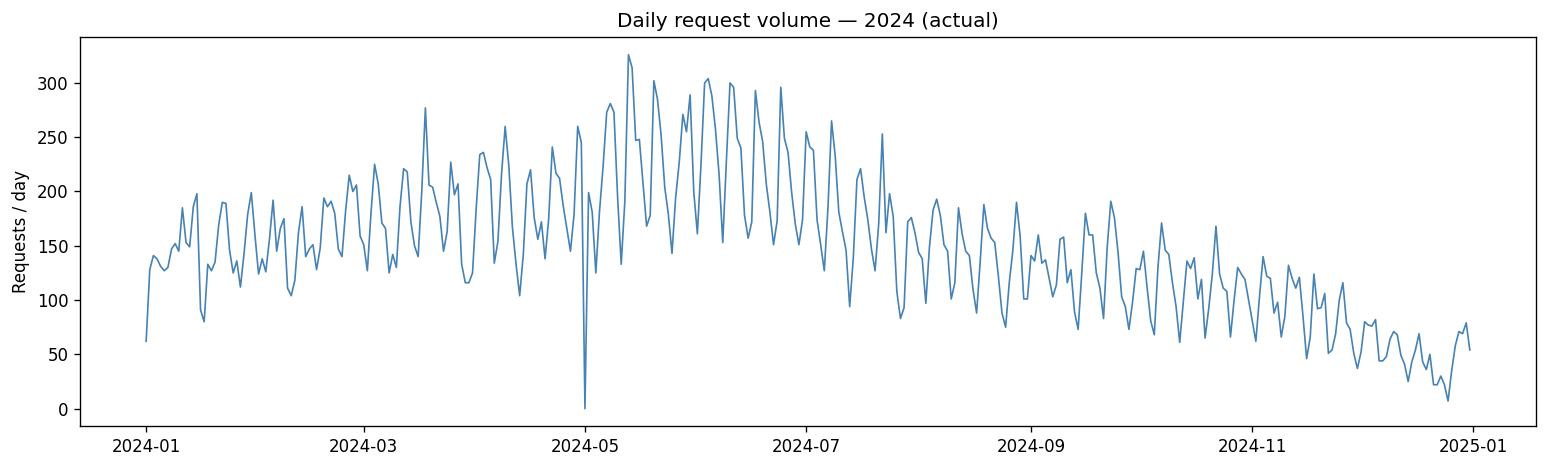

In [2]:
daily = (requests.assign(ds=requests['created'].dt.normalize())
         .groupby('ds').size().rename('y').reset_index())
# make the daily index continuous (fill any zero-activity days)
full  = pd.DataFrame({'ds': pd.date_range(daily['ds'].min(), daily['ds'].max(), freq='D')})
daily = full.merge(daily, on='ds', how='left').fillna({'y': 0})
print('Daily series:', daily['ds'].min().date(), '->', daily['ds'].max().date(), '| days', len(daily))
print('Mean/day:', round(daily['y'].mean(), 1), '| min', int(daily['y'].min()), '| max', int(daily['y'].max()))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily['ds'], daily['y'], color='steelblue', lw=1)
ax.set_title('Daily request volume — 2024 (actual)')
ax.set_ylabel('Requests / day')
plt.tight_layout()
plt.savefig(FIGURES + '29_daily_demand_2024.png', bbox_inches='tight')
plt.show()

## 2. Prophet model + 2025 forecast

**Flat trend** (`growth='flat'`) + weekly & yearly seasonality (additive) + UK England bank holidays as
holiday effects. We deliberately suppress trend extrapolation: with a single year, a fitted trend would
mistake the seasonal year-end trough for a downtrend and collapse the 2025 forecast. Flat growth yields
an honest planning baseline — 2025 repeats the 2024 level and seasonal shape (see Section 5).

Holiday effects supplied: 16


14:19:27 - cmdstanpy - INFO - Chain [1] start processing


14:19:27 - cmdstanpy - INFO - Chain [1] done processing


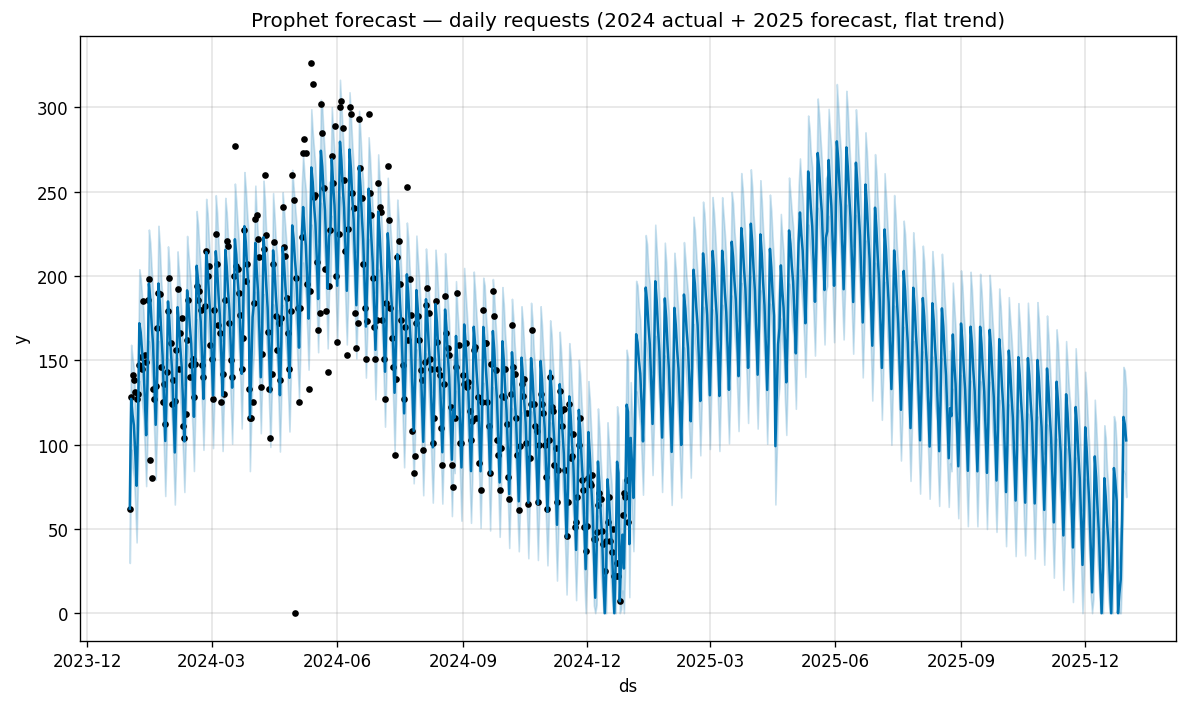

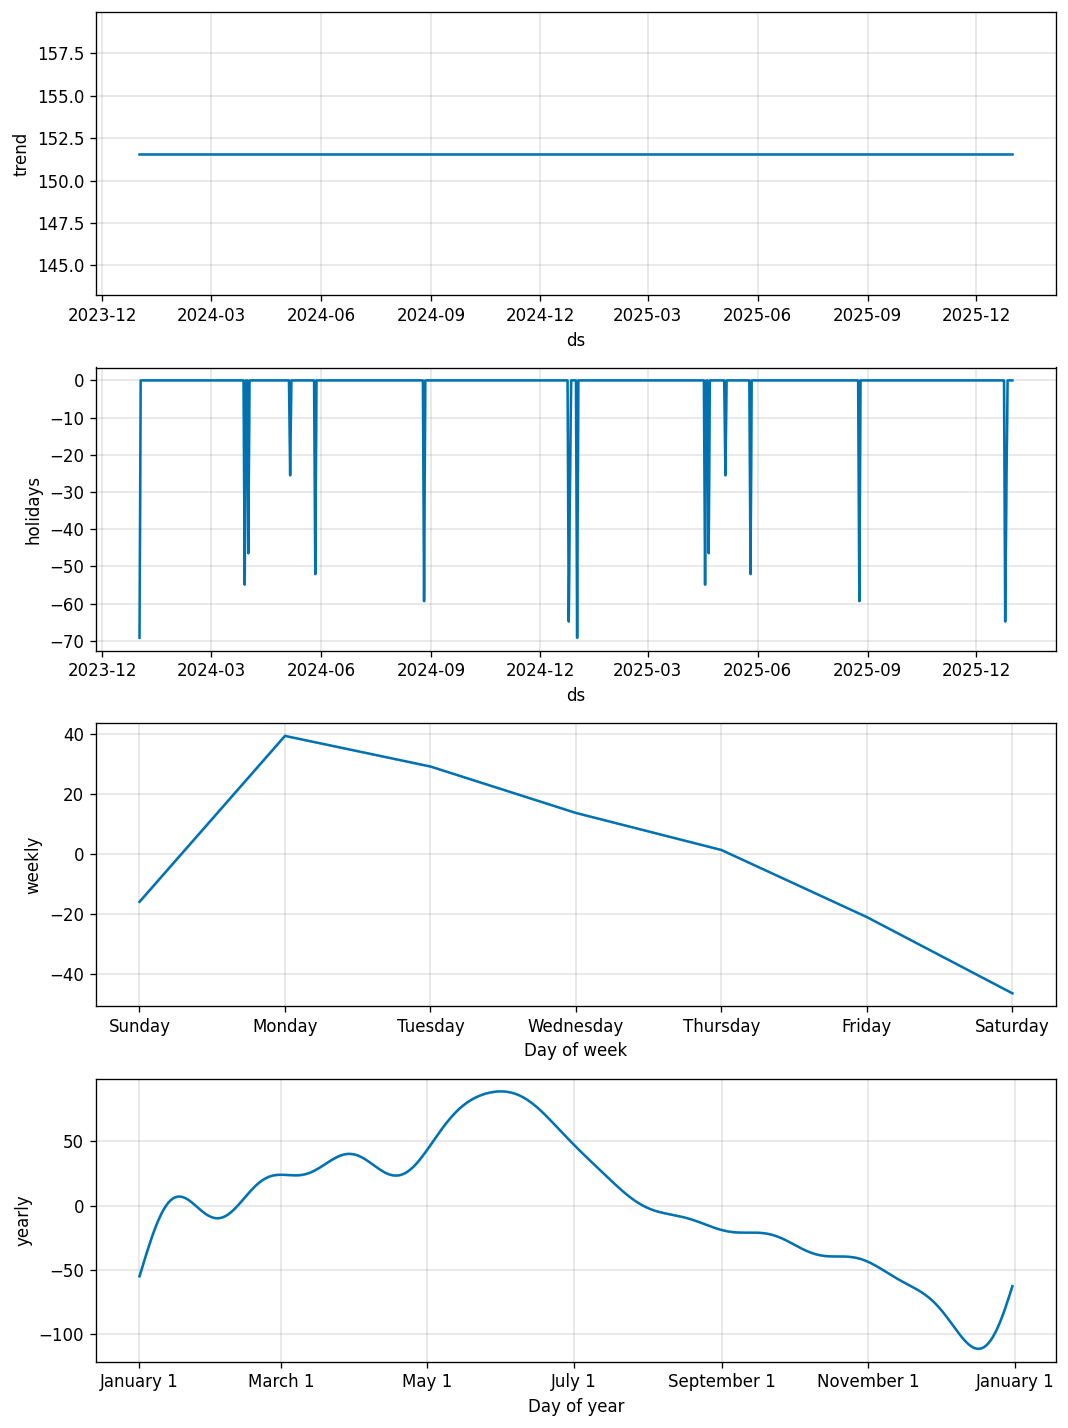

In [3]:
# UK England bank holidays as Prophet holiday effects
hol = pd.read_csv(RAW + 'uk_bank_holidays_2024_2025.csv', parse_dates=['date'])
hol_eng = (hol[hol['is_bank_holiday_england'] == 1][['date', 'holiday_name_england']]
           .rename(columns={'date': 'ds', 'holiday_name_england': 'holiday'}))
print('Holiday effects supplied:', len(hol_eng))

# growth='flat': with only ONE year of data we cannot separate TREND from SEASONALITY. The steep
# H2-2024 fall (Jun ~6.7k/mo -> Dec ~1.6k/mo) is the year-end seasonal trough, NOT a downtrend — a
# fitted trend would wrongly extrapolate it and collapse 2025 (~-88%). Flat growth gives the honest
# planning baseline: 2025 repeats the 2024 level with its seasonal shape + bank-holiday effects.
m = Prophet(growth='flat', weekly_seasonality=True, yearly_seasonality=True,
            daily_seasonality=False, holidays=hol_eng, seasonality_mode='additive')
m.fit(daily)

future = m.make_future_dataframe(periods=365, freq='D')
fc = m.predict(future)
for col in ['yhat', 'yhat_lower', 'yhat_upper']:
    fc[col] = fc[col].clip(lower=0)

fig = m.plot(fc)
plt.title('Prophet forecast — daily requests (2024 actual + 2025 forecast, flat trend)')
plt.tight_layout()
plt.savefig(FIGURES + '30_prophet_forecast.png', bbox_inches='tight')
plt.show()

fig2 = m.plot_components(fc)
plt.tight_layout()
plt.savefig(FIGURES + '31_prophet_components.png', bbox_inches='tight')
plt.show()

In [4]:
# 2025 demand totals
fc2025 = fc[(fc['ds'] >= '2025-01-01') & (fc['ds'] <= '2025-12-31')].copy()
req_2024_total = daily['y'].sum()
req_2025_total = fc2025['yhat'].clip(lower=0).sum()
lo = fc2025['yhat_lower'].clip(lower=0).sum()
hi = fc2025['yhat_upper'].clip(lower=0).sum()

print(f'2024 actual requests:   {req_2024_total:,.0f}')
print(f'2025 forecast requests: {req_2025_total:,.0f}  ({req_2025_total/req_2024_total - 1:+.1%} vs 2024)')
print(f'  80% interval:         {lo:,.0f} – {hi:,.0f}')

2024 actual requests:   55,104
2025 forecast requests: 54,971  (-0.2% vs 2024)
  80% interval:         43,450 – 66,654


## 3. Validation (rolling-origin cross-validation)

Prophet's `cross_validation` retrains on expanding windows and scores out-of-sample. This validates the
**weekly/short-horizon** signal — the part we can actually trust with one year of data.

In [5]:
# Rolling-origin backtest. With one year we can only credibly validate SHORT horizons (the weekly
# signal); yearly seasonality is not learnable inside a fold, so we cap the horizon at 21 days.
# Lead with MAE / RMSE — MAPE is inflated because many days have very low counts (weekends / holidays)
# and dividing by small actuals explodes the percentage.
cv = cross_validation(m, initial='270 days', period='30 days', horizon='21 days')
pm = performance_metrics(cv, rolling_window=1)   # single aggregated row across the horizon

mae, rmse, mape = pm['mae'].iloc[0], pm['rmse'].iloc[0], pm['mape'].iloc[0]
print('Rolling-origin backtest (horizon up to 21 days, 3 folds):')
print(f'  MAE : {mae:6.1f} requests/day   (series averages {daily["y"].mean():.0f}/day)')
print(f'  RMSE: {rmse:6.1f} requests/day')
print(f'  MAPE: {mape:6.0%}   (inflated by low-count weekend/holiday days — use MAE/RMSE)')
print()
print(f'  -> Typical daily error is ~{mae:.0f} on a ~{daily["y"].mean():.0f}/day base '
      f'({mae/daily["y"].mean():.0%} of the mean) at a 1-3 week horizon.')

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/3 [00:00<?, ?it/s]

14:19:30 - cmdstanpy - INFO - Chain [1] start processing


14:19:30 - cmdstanpy - INFO - Chain [1] done processing


 33%|███▎      | 1/3 [00:00<00:00,  2.58it/s]

...

14:19:31 - cmdstanpy - INFO - Chain [1] start processing


14:19:31 - cmdstanpy - INFO - Chain [1] done processing


100%|██████████| 3/3 [00:01<00:00,  2.83it/s]

100%|██████████| 3/3 [00:01<00:00,  2.79it/s]

Rolling-origin backtest (horizon up to 21 days, 3 folds):
  MAE :   85.9 requests/day   (series averages 151/day)
  RMSE:  157.0 requests/day
  MAPE:   131%   (inflated by low-count weekend/holiday days — use MAE/RMSE)

  -> Typical daily error is ~86 on a ~151/day base (57% of the mean) at a 1-3 week horizon.


## 4. Cascade: demand → bookings → GMV

Forecast requests are distributed across the 10 macro categories by their **2024 request share**, then
converted to bookings (× 2024 segment conversion) and **GMV** (× 2024 avg ticket). Two scenarios:
**Base** (2024 conversion holds) and **Uplift** (laggard segments reach the top-quartile conversion — the
opportunity quantified in `02_analysis` Section 7). *All £ are GMV; Togather revenue is a commission % of it.*

In [6]:
TAG_GROUPS = {
    'Pizza':'Street Food','Burgers':'Street Food','Hot Dogs':'Street Food','Fries':'Street Food',
    'Wraps':'Street Food','Sandwiches':'Street Food','Fish and Chips':'Street Food',
    'Fried Chicken':'Street Food','Mac & Cheese':'Street Food',
    'BBQ':'BBQ & Meats','Hog Roast':'BBQ & Meats','Pulled Meats':'BBQ & Meats','Pies':'BBQ & Meats',
    'Asian':'Asian & Indian','Chinese':'Asian & Indian','Indian':'Asian & Indian','Japanese':'Asian & Indian',
    'Thai':'Asian & Indian','Vietnamese':'Asian & Indian','Korean':'Asian & Indian','Curries':'Asian & Indian',
    'Mexican':'World & Fusion','Caribbean':'World & Fusion','South American':'World & Fusion',
    'African':'World & Fusion','Middle Eastern':'World & Fusion','Fusion':'World & Fusion','Seafood':'World & Fusion',
    'Italian':'European','French':'European','Greek':'European','Spanish':'European','Mediterranean':'European',
    'Pasta':'European','Modern British':'European','Fine dining':'European',
    'Dessert':'Sweet & Desserts','Ice Cream':'Sweet & Desserts','Waffles':'Sweet & Desserts',
    'Doughnuts & Churros':'Sweet & Desserts','Crêpes':'Sweet & Desserts','Afternoon Tea':'Sweet & Desserts',
    'Wedding Cake':'Sweet & Desserts',
    'Canapés':'Sharing & Events','Salads':'Sharing & Events','Grazing boards or tables':'Sharing & Events',
    'Gifting & Hampers':'Sharing & Events','Breakfast':'Sharing & Events','Seasonal':'Sharing & Events',
    'Festive':'Sharing & Events',
    'Strictly Vegan':'Dietary','Vegan':'Dietary','Sustainable':'Dietary',
    'Indoor bar':'Bar & Drinks','Horsebox bar':'Bar & Drinks','Oh-wow outdoor bar':'Bar & Drinks',
    'Outdoors':'Bar & Drinks','Rooftop':'Bar & Drinks','Beer & Cider':'Bar & Drinks',
    'Waiters':'Service','Bartenders':'Service','Vehicle':'Service','Delivery':'Service',
}
def apply_macro(tag):
    if pd.isna(tag):
        return None
    return TAG_GROUPS.get(str(tag).strip(), 'Other')

requests['customer_macro'] = requests['priority_tag'].map(apply_macro)

# 2024 request-level conversion + GMV per segment (GMV = sum of booked quote prices)
merged = requests.merge(quotes[['event_request_id', 'booked', 'quote_price']],
                        on='event_request_id', how='left')
merged['is_booked'] = merged['booked'].fillna(0).astype(int)
booked   = merged[merged['booked'] == 1]
req_gmv  = booked.groupby('event_request_id')['quote_price'].sum()
isb      = merged.groupby('event_request_id')['is_booked'].max()

rl = requests[['event_request_id', 'customer_macro']].copy()
rl['is_booked'] = rl['event_request_id'].map(isb).fillna(0).astype(int)
rl['gmv']       = rl['event_request_id'].map(req_gmv).fillna(0.0)

seg = rl.groupby('customer_macro').agg(
    requests = ('event_request_id', 'count'),
    bookings = ('is_booked', 'sum'),
    gmv      = ('gmv', 'sum'),
)
seg['share']      = seg['requests'] / seg['requests'].sum()
seg['conversion'] = seg['bookings'] / seg['requests']
seg['avg_ticket'] = (seg['gmv'] / seg['bookings'].replace(0, np.nan)).fillna(0.0)

# distribute 2025 forecast demand by 2024 segment share
seg['req_2025']         = seg['share'] * req_2025_total
seg['bookings_2025']    = seg['req_2025'] * seg['conversion']
seg['gmv_2025_base']    = seg['bookings_2025'] * seg['avg_ticket']

# uplift scenario: lift laggards to top-quartile conversion
bench = seg['conversion'].quantile(0.75)
seg['conv_uplift']      = seg['conversion'].clip(lower=bench)
seg['gmv_2025_uplift']  = seg['req_2025'] * seg['conv_uplift'] * seg['avg_ticket']

out = seg.sort_values('gmv_2025_base', ascending=False)
print(f'Benchmark (top-quartile) conversion: {bench:.2%}   |   all £ = GMV\n')
print(out.assign(
    conversion = lambda d: d['conversion'].map('{:.2%}'.format),
    avg_ticket = lambda d: d['avg_ticket'].map('£{:,.0f}'.format),
    req_2025   = lambda d: d['req_2025'].map('{:,.0f}'.format),
    gmv_base   = lambda d: d['gmv_2025_base'].map('£{:,.0f}'.format),
    gmv_uplift = lambda d: d['gmv_2025_uplift'].map('£{:,.0f}'.format),
)[['req_2025', 'conversion', 'avg_ticket', 'gmv_base', 'gmv_uplift']].to_string())

Benchmark (top-quartile) conversion: 7.98%   |   all £ = GMV

                 req_2025 conversion avg_ticket    gmv_base  gmv_uplift
customer_macro                                                         
Street Food        15,128      7.76%     £1,570  £1,843,755  £1,895,140
World & Fusion      6,727      8.31%     £1,620    £905,878    £905,878
BBQ & Meats        10,467      5.06%     £1,696    £897,830  £1,416,047
European            7,412      5.87%     £1,741    £756,947  £1,029,507
Sharing & Events    3,714      8.05%     £2,439    £729,009    £729,009
Asian & Indian      6,185      5.55%     £1,862    £639,390    £918,590
Sweet & Desserts    4,305      5.99%     £1,549    £399,321    £531,794
Dietary             1,021      6.15%     £2,040    £128,040    £166,207
Bar & Drinks            7     16.67%     £1,512      £1,725      £1,725
Service                 5      0.00%         £0          £0          £0


=== 2025 cascade summary (all £ = GMV; Togather revenue = commission % of GMV) ===
2024 actual booked GMV:     £6,332,402
2025 forecast bookings (base):  3,661
2025 forecast GMV (base):   £6,301,895  (-0.5% vs 2024)
2025 forecast GMV (uplift): £7,593,896  (+£1,292,001 from lifting laggards)


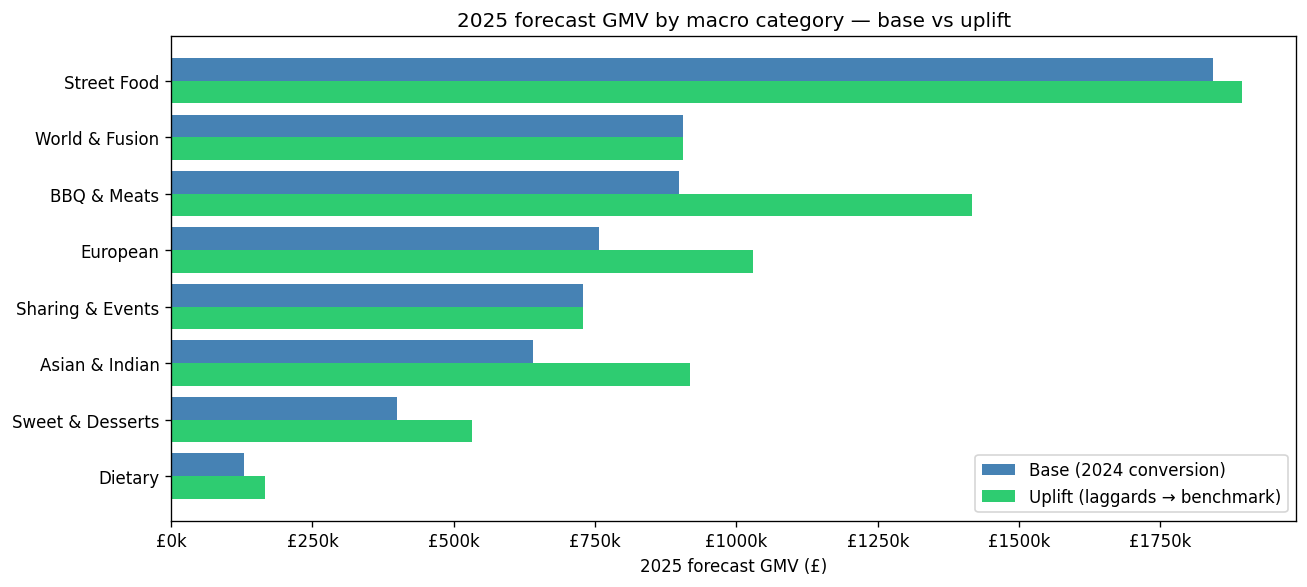

In [7]:
gmv_2024         = rl['gmv'].sum()
bookings_2025    = seg['bookings_2025'].sum()
gmv_2025_base    = seg['gmv_2025_base'].sum()
gmv_2025_uplift  = seg['gmv_2025_uplift'].sum()

print('=== 2025 cascade summary (all £ = GMV; Togather revenue = commission % of GMV) ===')
print(f'2024 actual booked GMV:     £{gmv_2024:,.0f}')
print(f'2025 forecast bookings (base):  {bookings_2025:,.0f}')
print(f'2025 forecast GMV (base):   £{gmv_2025_base:,.0f}  ({gmv_2025_base/gmv_2024 - 1:+.1%} vs 2024)')
print(f'2025 forecast GMV (uplift): £{gmv_2025_uplift:,.0f}  (+£{gmv_2025_uplift - gmv_2025_base:,.0f} from lifting laggards)')

# chart: base vs uplift GMV by segment
plot = out[out['req_2025'] > 100]
y = np.arange(len(plot))
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(y - 0.2, plot['gmv_2025_base'],   height=0.4, color='steelblue', label='Base (2024 conversion)')
ax.barh(y + 0.2, plot['gmv_2025_uplift'], height=0.4, color='#2ecc71',   label='Uplift (laggards → benchmark)')
ax.set_yticks(y); ax.set_yticklabels(plot.index)
ax.invert_yaxis()
ax.set_xlabel('2025 forecast GMV (£)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'£{v/1000:.0f}k'))
ax.set_title('2025 forecast GMV by macro category — base vs uplift')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES + '32_forecast_revenue_cascade.png', bbox_inches='tight')
plt.show()

## 5. Limitations (read before quoting these numbers)

- **One year of data (2024 only).** Prophet's **yearly** seasonality is fit on a *single* cycle, so the
  annual shape cannot be cross-validated — only the **weekly / short-horizon** signal is genuinely
  validated (Section 3). Treat the 2025 annual total as a **planning baseline**, not a precise prediction.
- **Cascade assumes 2024 segment conversion and ticket hold in 2025.** Macro conditions (food CPI, rates,
  consumer confidence) could shift these; the external variables gathered in `data/raw/` are the natural
  next step to flex these assumptions.
- **Uplift scenario is mechanical** (lift laggards to top-quartile conversion). It sizes the *prize*, not
  the *cost* of capturing it — pair with the supply-side recommendations in `02_analysis`.
- Forecast values are clipped at zero; intervals widen materially in H2 2025.